Fetching historical data...


[*********************100%***********************]  4 of 4 completed


Handling missing values...
Calculating log returns...
Generating covariance matrix...
Generating correlation matrix...
Processed datasetsaved to data\processed


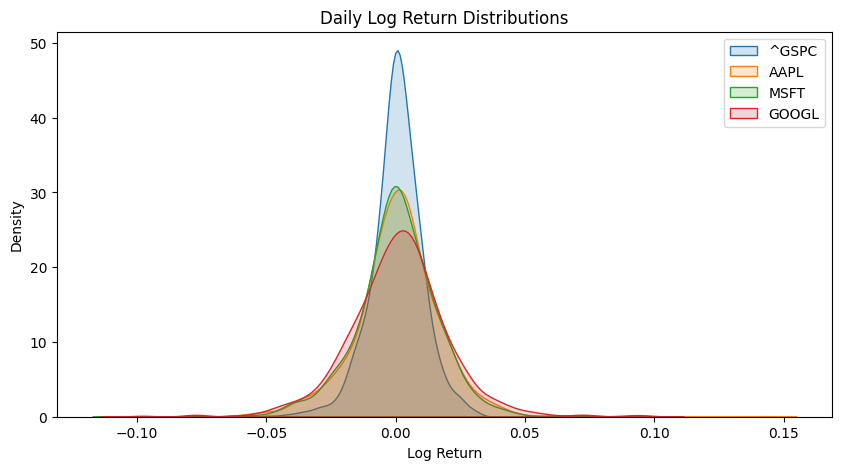

In [1]:
import os
import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
tickers = ['^GSPC','AAPL', 'MSFT', "GOOGL"]
print("Fetching historical data...")
raw_data=yf.download(tickers,period="5y")['Close']
print("Handling missing values...")
cleaned_data=raw_data.ffill().bfill()
print("Calculating log returns...")
log_returns = np.log(cleaned_data / cleaned_data.shift(1)).dropna()
print("Generating covariance matrix...")
cov_matrix = log_returns.cov()
print("Generating correlation matrix...")
corr_matrix = log_returns.corr()
output_dir=os.path.join("data","processed")
os.makedirs(output_dir, exist_ok=True)
log_returns.to_csv(os.path.join(output_dir,"processed_log_returns.csv"))
print(f"Processed datasetsaved to {output_dir}")
plt.figure(figsize=(10, 5))
for ticker in tickers:
    sns.kdeplot(log_returns[ticker], label=ticker,fill=True, alpha=0.2)
plt.title("Daily Log Return Distributions")
plt.xlabel("Log Return")
plt.legend()
plt.show()